<a href="https://colab.research.google.com/github/ninabordo03/ninabordo03/blob/main/DogBreed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1- Loading the data from kaggle

2- Load labels csv for labels that contain image ID and breed

3- Checking the breed count

4- One-hot encoding on labels dats prediction column

5- Load the images, convert them to an array and normalize them

6- Check the shape and size of x and y data

7- Building the model network architecture

8- Split the data and fit it into the model and create an accuracy plot

API token: KGAT_cf826c84137705f0eb2580e5be71c9e7

To use this token, set the KAGGLE_API_TOKEN environment variable: export KAGGLE_API_TOKEN=KGAT_cf826c84137705f0eb2580e5be71c9e7

After setting KAGGLE_API_TOKEN, you can use the client as follows: kaggle competitions list

In [ ]:
#from google.colab import files
#files.upload()

In [ ]:
# install the kaggle API client
!pip install -q kaggle

In [ ]:
# The Kaggle API client expects this file to be in ~/.kaggle, so move it there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle.json
# This permissions change avoids a warning on Kaggle tool startup
!chmod 600 ~/.kaggle/kaggle.json

Setting up Kaggle using Kaggle API

In [ ]:
!mkdir dog_dataset
%cd dog_dataset

To store the data we will create a new directory and make it as current working directory

In [ ]:
!kaggle datasets list -s dogbreedidfromcomp

Searching Kaggle for the required dataset using search option(-s) with title 'dogbreedidfromcomp'. We can also use different search options like searching competitions, notebooks, kernels, datasets, etc

In [ ]:
# Downloading dataset and coming out of directory
!kaggle datasets download catherinehorng/dogbreedidfromcomp
%cd ..

Dataset URL: https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp
License(s): unknown
100% 691M/691M [00:31<00:00, 22.6MB/s]

/content


After searching the data next step would be downloading the data into collab notebook using references found in search option

In [ ]:
# Unzipping downloaded file and removing unusable file
!unzip dog_dataset/dogbreedidfromcomp.zip -d dog_dataset
!rm dog_dataset/dogbreedidfromcomp.zip
!rm dog_dataset/sample_submission.csv

Streaming output truncated to the last 5000 lines.
  inflating: dog_dataset/train/83bc62b0fffa99a9c94ba0b67a5f7395.jpg  
  inflating: dog_dataset/train/83bcff6b55ee179a7c123fa6103c377a.jpg  
  inflating: dog_dataset/train/83be6d622ab74a5e7e08b53eb8fd566a.jpg  
  inflating: dog_dataset/train/83c2d7419b0429b9fe953bc1b6cddbec.jpg  
  inflating: dog_dataset/train/83cf7d7cd2a759a93e2ffd95bea9c6fb.jpg  
  inflating: dog_dataset/train/83d405858f0931722ef21e8ac0adee4d.jpg  
  inflating: dog_dataset/train/83d4125a4c3c7dc5956563276cb1cd74.jpg  
  inflating: dog_dataset/train/83f0bb565b2186dbcc6a9d009cb26ff2.jpg  
  inflating: dog_dataset/train/83fad0718581a696132c96c166472627.jpg  
  inflating: dog_dataset/train/83fbbcc9a612e3f712b1ba199da61f20.jpg  
  inflating: dog_dataset/train/8403d8936430c2f05ab7d74d23c2c0cb.jpg  
  inflating: dog_dataset/train/8406d837b2d7fac1c3cd621abb4c4f9e.jpg  
  inflating: dog_dataset/train/840b67d26e5e43f8eb6430f62d4ba1ac.jpg  
  inflating: dog_dataset/train/840db91b

In [ ]:
# Important library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam

In [ ]:
labels_all = pd.read_csv('dog_dataset/labels.csv')
labels_all.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
breed_counts = labels_all['breed'].value_counts()
breed_counts.head()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114


In [51]:
# selecting first 3 breeds due to computation power
selected = ['scottish_deerhound', 'maltese_dog', 'afghan_hound']
labels = labels_all[(labels_all['breed'].isin(selected))]
labels = labels.reset_index()
labels.head()

,index,id,breed
0,9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound
1,12,00693b8bc2470375cc744a6391d397ec,maltese_dog
2,79,01e787576c003930f96c966f9c3e1d44,scottish_deerhound
3,90,022b34fd8734b39995a9f38a4f3e7b6b,maltese_dog
4,146,0379145880ad3978f9b80f0dc2c03fba,afghan_hound


In [ ]:
x_data = np.zeros((len(labels), 224, 224, 3), dtype = 'float32')
y_data = label_binarize(labels['breed'], classes = selected)
for i in tqdm(range(len(labels))):
  img = image.load_img('dog_dataset/train/%s.jpg' % labels['id'][i], target_size=(224, 224))
  img = image.img_to_array(img)
  x = np.expand_dims(img.copy(), axis = 0)
  x_data[i] = x/255.0
print(f'Train images shape: {x_data.shape} Size: {x_data.size}')
print(f'One hot encoded output shape: {y_data.shape} Size: {y_data.size}')

100%|██████████| 359/359 [00:00<00:00, 485.95it/s]

Train images shape: (359, 224, 224, 3) Size: 54039552
One hot encoded output shape: (359, 3) Size: 1077


In [ ]:
# Building the model

model = Sequential()

model.add(Conv2D(filters = 64, kernel_size = (5,5), activation ='relu', input_shape = (224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 16, kernel_size = (7,7), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 8, kernel_size = (5,5), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation = "relu", kernel_regularizer = 'l2'))
model.add(Dense(64, activation = "relu", kernel_regularizer = 'l2'))
model.add(Dense(len(selected), activation = "softmax"))

model.compile(loss = 'categorical_crossentropy', optimizer = Adam(0.0001),metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Splitting the data set into training and testing data sets
x_train_and_val, x_test, y_train_and_val, y_test = train_test_split(x_data, y_data, test_size = 0.1)
# Splitting the training data set into training and validation data sets
x_train, x_val, y_train, y_val = train_test_split(x_train_and_val, y_train_and_val, test_size = 0.1)

In [ ]:
x_test

array([[[[0.7607843 , 0.7647059 , 0.78431374],
         [0.8980392 , 0.90588236, 0.9019608 ],
         [0.92156863, 0.9411765 , 0.91764706],
         ...,
         [0.65882355, 0.6862745 , 0.48235294],
         [0.22352941, 0.27450982, 0.10196079],
         [0.49411765, 0.56078434, 0.39607844]],

        [[0.5411765 , 0.54509807, 0.5647059 ],
         [0.93333334, 0.9490196 , 0.9529412 ],
         [0.8235294 , 0.84705883, 0.84705883],
         ...,
         [0.44705883, 0.49411765, 0.23529412],
         [0.4       , 0.45490196, 0.24705882],
         [0.11764706, 0.1882353 , 0.        ]],

        [[0.57254905, 0.5882353 , 0.6       ],
         [0.64705884, 0.6666667 , 0.68235296],
         [0.59607846, 0.6156863 , 0.6392157 ],
         ...,
         [0.5803922 , 0.654902  , 0.3372549 ],
         [0.48235294, 0.5058824 , 0.27058825],
         [0.5372549 , 0.54901963, 0.33333334]],

        ...,

        [[0.84705883, 0.93333334, 0.6509804 ],
         [0.65882355, 0.7372549 , 0.49019608]

In [ ]:
# training the model
epochs, batch_size = 5, 128
history = model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val, y_val))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - accuracy: 0.3759 - loss: 4.8625 - val_accuracy: 0.3939 - val_loss: 4.8327
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.3793 - loss: 4.8250 - val_accuracy: 0.4242 - val_loss: 4.7991
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.4241 - loss: 4.7887 - val_accuracy: 0.4545 - val_loss: 4.7658
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.4552 - loss: 4.7528 - val_accuracy: 0.4545 - val_loss: 4.7313
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.4793 - loss: 4.7158 - val_accuracy: 0.4242 - val_loss: 4.6976


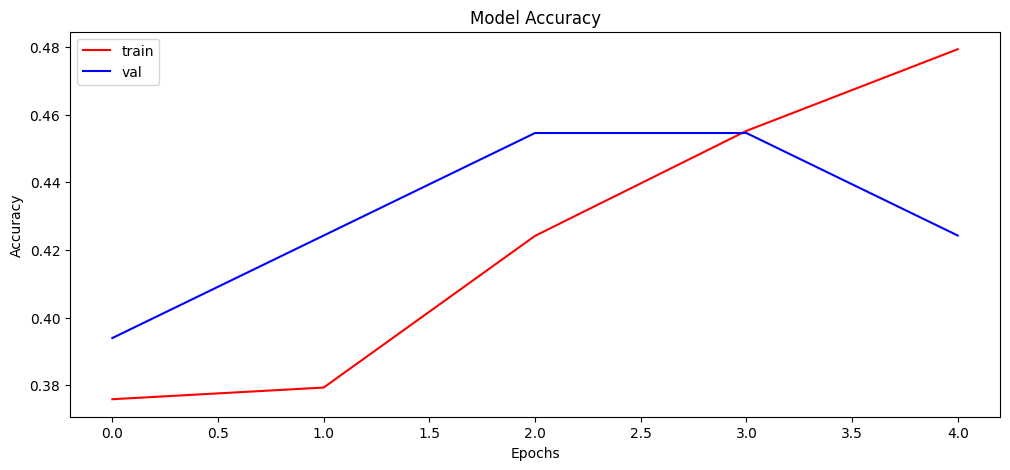

In [ ]:
# plot the training history

plt.figure(figsize = (12, 5))
plt.plot(history.history['accuracy'], color = 'r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

In [ ]:
y_pred = model.predict(x_test)
score = model.evaluate(x_test, y_test)
print('Accuracy over the test set: \n ', round((score[1]*100), 2), '%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.5556 - loss: 4.6810
Accuracy over the test set: 
  55.56 %


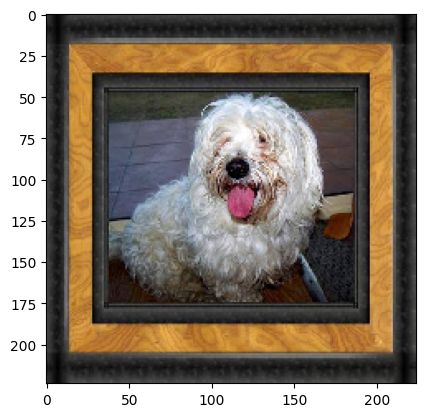

Originally :  maltese_dog
Predicted :  maltese_dog


In [ ]:
# Plotting image to compare
plt.imshow(x_test[1,:,:,:])
plt.show()

# Finding max value from predition list and comaparing original value vs predicted
print("Originally : ",labels['breed'][np.argmax(y_test[1])])
print("Predicted : ",labels['breed'][np.argmax(y_pred[1])])

In [ ]:
model.save('dog_breed.keras')

In [44]:
from google.colab import files
newdog = files.upload()

Saving proper-scottish-dog-the-scottish-deerhound-is-a-large-breed-v0-th78sb7eemm91.webp to proper-scottish-dog-the-scottish-deerhound-is-a-large-breed-v0-th78sb7eemm91 (3).webp


{'proper-scottish-dog-the-scottish-deerhound-is-a-large-breed-v0-th78sb7eemm91 (3).webp': b'RIFF\x0e\x91\x01\x00WEBPVP8 \x02\x91\x01\x00\xf0\xc3\x05\x9d\x01*\x80\x02\xc2\x03>Q"\x8eE#\xa2!"\xa7x[\xd0p\n\tgg\x11\x81\xd7\xde\xd9\xc4\xc3\xdc\x7f\xca\xef\xc2\xc0\xfe\xdb\xe4\x9f\xe5\xb2?>\xcf\xce\xef\xca;3:i\xc7\xfd@\x97h\xa8\x10\xf4\xa5\x03\xf4\xd7a\xbd\x7f\xf5?(\xedq\xfc\xf3\xfa\xf7\xfb\xeea\x1c\x87\xf9\xb7\xf9\xcf\xef\xff\xbb>~\xfe\xcd\xfa\xb3\xe4\r\xe7\x7f\xd8\xfd\x80\x7f\x92\xff=\xff\'\xf7\x19\xf3/\xfc\'q\xf6\xdc\xfb\x00\x7f[\xff\x15\xff\x0f\xee\xd3\xdd\xdf\x98_\xd5\xff\xd9\xf9\xcez\xdc\xff\x0f\xe8G\xfa_\xf7\xdf\xfa\xdf\xe1\xfe\x00\xffW?\xd2\xfb\x01\xff\x13\xf6\xb3\xd0\x97\xee_\xe9\x7f\xf6\xff\xa7\xf7\'\xfb\x05\xff7\xfc6K\xcfH\xdc\x0b\xd6fG\x97\xf1\xc7d\x7f\xcc\xf9\xc7\xfb\x07}_S\xbf\xd2\xbdH\xfa\x1e\xf9\xd0\xf3\x85\xf5K\xfd\x87\xd1\x1f\xaa\xffz\xe6\xd3\xcf]\xfc\x19\xfc\x9f\xeb\xff\xe4\x7f\x83\xffM\xee3\xfa\xbeM\xfds\xfco\xfe\xbf\xf0\xbdH\xfey\xfaG\xd3\xbe\x9f\xff\xe7\xffI\xe5_\xd0?\xfb

Uploading and image, preprocessing it to fit the model and testing if it predicts right

In [52]:
import cv2
img = cv2.imread('proper-scottish-dog-the-scottish-deerhound-is-a-large-breed-v0-th78sb7eemm91.webp')
img = cv2.resize(img, (224, 224))
img = np.zeros((1, 224, 224, 3), dtype = 'float32')
x = np.expand_dims(img.copy(), axis = 0)
x = x/255.0
img_bgr = cv2.cvtColor(x, cv2.COLOR_RGB2BGR)

In [56]:
pred = model.predict(img)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


array([[0.333797  , 0.3328902 , 0.33331272]], dtype=float32)

In [59]:
print("Predicted : ",labels['breed'][np.argmax(pred)])

Predicted :  scottish_deerhound
